### **Load libraries**

In [61]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import risk_kit as rk
import importlib

In [62]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

### **Load data**

In [64]:
rets = pd.read_csv('../temp_references/selected_stocks_rets.csv', index_col=0)
stocks = pd.read_csv('../temp_references/selected_stocks_stocks.csv', index_col=0)

In [65]:
expected_returns = pd.read_csv('../temp_references/expected_returns.csv', index_col=0, header=None).iloc[:,0]
expected_covmat = pd.read_csv('../temp_references/expected_covmat.csv', index_col=0)

In [66]:
# Define the number of periods per year for all calculations
# 252 is an approximation for daily
# 54 for weekly
# 12 for monthly
periods_per_year = 54

# **Initial examination**

In [67]:
summary_stats = rk.summary_stats(rets, periods_per_year=periods_per_year, riskfree_rate=0)
summary_stats

,Annualized Return,Annualized Volatility,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
AT0000827209,-0.012053,0.404958,1.205217,14.630279,0.056073,0.112196,-0.029763,-0.729761
AU000000CQR9,0.047657,0.206895,-1.721566,20.256901,0.047441,0.061223,0.230344,-0.404427
AU000000GBE0,0.216784,1.078993,5.875076,77.925444,-0.332640,0.203561,0.200913,-0.836093
AU000000HLO6,0.018169,0.577690,1.806311,25.601740,0.044958,0.153163,0.031452,-0.849735
AU000000HZN8,0.270663,0.490634,0.431374,6.999373,0.089364,0.137999,0.551659,-0.729032
...,...,...,...,...,...,...,...,...
VGG2423W1077,-0.056352,0.705675,2.725510,19.722654,0.034740,0.155833,-0.079856,-0.918310
VGG4001R1047,-0.017701,0.483435,0.871069,6.137794,0.085046,0.120382,-0.036614,-0.829193
ZAE000026480,0.010202,0.258980,-0.113085,5.949257,0.056184,0.078520,0.039393,-0.561041
ZAE000190252,-0.062586,0.423742,1.615280,45.886903,0.015157,0.120428,-0.147698,-0.843208


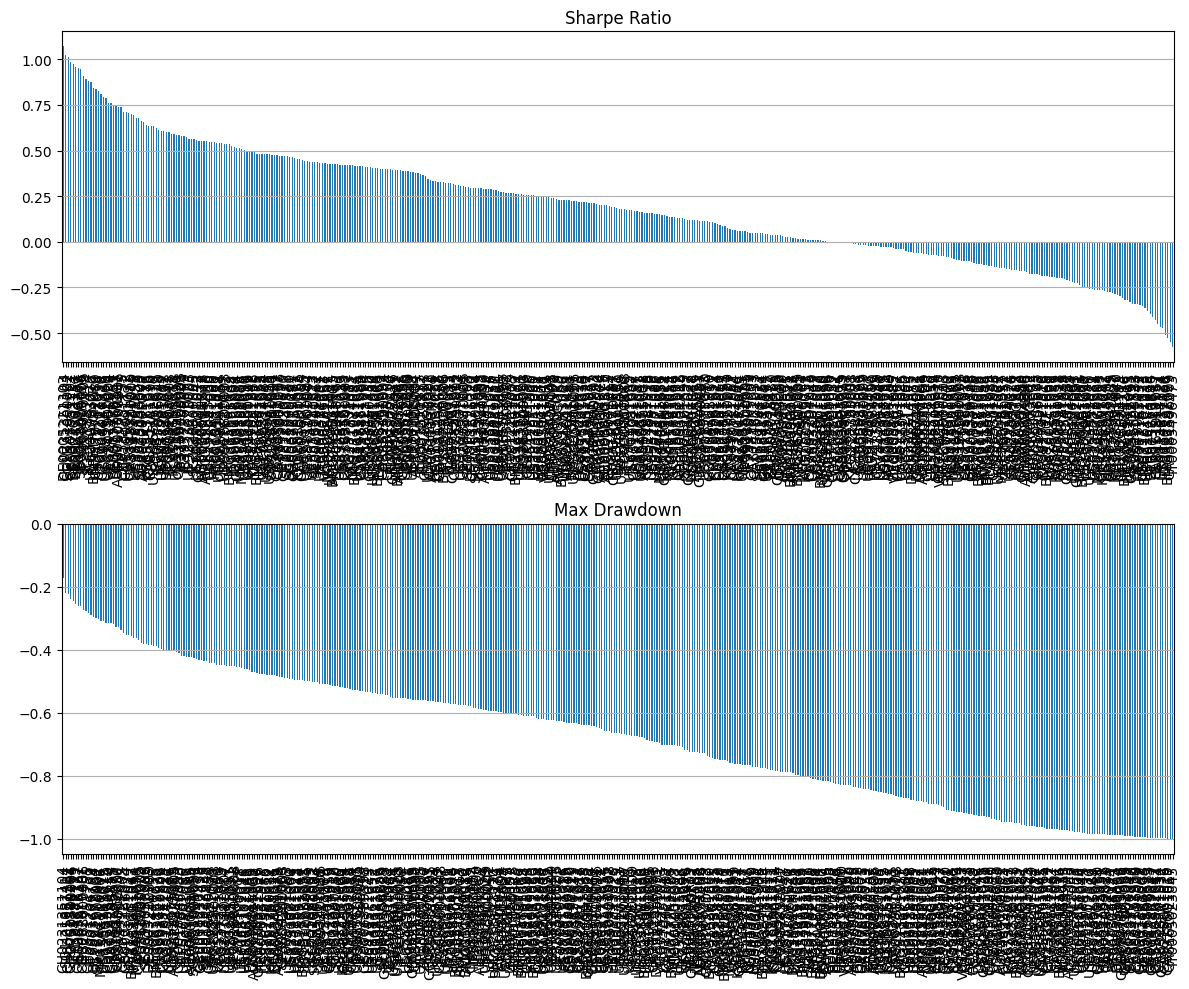

In [68]:
# Plot some return, volatility, and risk rankings to get a view of relevant stocks
summary_stats = rk.summary_stats(rets, periods_per_year=periods_per_year)
#plot1_series = summary_stats['Annualized Return'].sort_values(ascending=False)
#plot2_series = summary_stats['Annualized Volatility'].sort_values(ascending=True)
#plot1_series = summary_stats['Cornish-Fisher VaR (5%)'].sort_values(ascending=False)
#plot2_series = summary_stats['Historic CVaR (5%)'].sort_values(ascending=False)
plot1_series = summary_stats['Sharpe Ratio'].sort_values(ascending=False)
plot2_series = summary_stats['Max Drawdown'].sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
plot1_series.plot.bar(ax = axes[0], legend=False, title=plot1_series.name)
plot2_series.plot.bar(ax=axes[1], legend=False, title=plot2_series.name)
axes[0].grid(axis='y')
axes[1].grid(axis='y')
plt.tight_layout()

In [69]:
# Identify stock pairs with very high correlation

# Generate correlation matrix
corr_mat = rets.corr()
# Generate a mask to exclude  duplicated pairs
#mask = np.triu(np.ones_like(corr_mat))
#corr_mat = corr_mat*mask
# Convert the matrix into a dataframe structured as a list of pairs with their respective correlations
stack_corr = pd.DataFrame(corr_mat.stack())
stack_corr = stack_corr[stack_corr[0] < 1]
stack_corr = stack_corr[stack_corr[0] != 0]
stack_corr.index.names = ['Stock 1', 'Stock 2']
stack_corr.reset_index(inplace=True)
#(abs(stack_corr[0]) > .7).sum()

# Filter to visualize only the pairs with very high correlations
high_corrs = stack_corr[stack_corr[0] >= 0.8].sort_values(by=0, ascending=False)
high_corrs

,Stock 1,Stock 2,0
23426,BMG611881019,BMG611881274,0.988352
23867,BMG611881274,BMG611881019,0.988352
186529,US9478901096,US97650W1080,0.876810
189170,US97650W1080,US9478901096,0.876810
141070,US2527843013,US70509V1008,0.872330
173191,US70509V1008,US2527843013,0.872330
161298,US6292093050,US5528481030,0.826851
147217,US5528481030,US6292093050,0.826851
185647,US9293281021,US97650W1080,0.816143
189168,US97650W1080,US9293281021,0.816143


In [70]:
# Check the average correlation coefficient of each stock
stack_corr.groupby('Stock 1')[0].mean().sort_values(ascending=False)

Stock 1
US00912X3026    0.274332
US97650W1080    0.259739
US9290891004    0.259525
US70509V1008    0.257814
US96208T1043    0.253216
                  ...   
CA89186Q1019    0.004668
SE0023261599    0.003827
SG1CE4000000    0.003082
CA9219661076    0.000958
GB00B28V9347   -0.002783
Name: 0, Length: 442, dtype: float64

# **Identify Combination with the maximum Sharpe-Ratio**

In [71]:
# Based on historical returns
n_periods = 162
# returns = rk.summary_stats(rets.iloc[-n_periods:], periods_per_year=periods_per_year)['Annualized Return']
# covmat = rets.iloc[-n_periods:].cov()

# Based on predicted returns
returns = expected_returns
covmat = expected_covmat

In [72]:
# Loop that calculates the combination that maximizes the Sharpe ratio several times until no stock has less than 5% of weight
rf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%
max_weight = 0.15 # The maximum weight allowed for a stock
min_weight = 0.05 # The minimum weight allowed for a stock
initial_weights = rk.msr_tuned(riskfree_rate=rf_rate,
                         returns=returns,
                         covmat=covmat,
                         max_weight=max_weight,
                         periods_per_year=periods_per_year,
                         debug=True)
optimal_allocation = pd.DataFrame(data=initial_weights, index=returns.index, columns=['Weights']).sort_values(by='Weights')

iteration = 0
while len(optimal_allocation) > 2:
    iteration += 1
    # Cumulative sum of weights (already sorted ascending)
    cum_weights = optimal_allocation['Weights'].cumsum()
    # A stock is dropped if its cumulative weight is still below the threshold
    failing_mask = cum_weights < min_weight
    if not failing_mask.any():
        break  # all cumulative weights meet the threshold — done
    n_dropped = failing_mask.sum()
    print(f"  [pass {iteration}] Dropping {n_dropped} stock(s) with cumulative weight < {min_weight:.0%}: "
          f"{list(optimal_allocation[failing_mask].index)}")
    # Drop the entire sub-threshold batch at once
    optimal_allocation = optimal_allocation[~failing_mask]
    if len(optimal_allocation) <= 2:
        break
    w = rk.msr_tuned(
        riskfree_rate=rf_rate,
        returns=returns[optimal_allocation.index],
        covmat=covmat.loc[optimal_allocation.index, optimal_allocation.index],
        max_weight=max_weight,
        periods_per_year=periods_per_year,
        debug=True
    )
    optimal_allocation = (
        pd.DataFrame(w, index=optimal_allocation.index, columns=['Weights'])
        .sort_values(by='Weights')
    )

# while optimal_allocation['Weights'].min() < min_weight and len(optimal_allocation) > 2:
#     optimal_allocation = optimal_allocation.iloc[1:]
#     w = rk.msr_tuned(
#         riskfree_rate=rf_rate, 
#         returns=returns[optimal_allocation.index],
#         covmat=covmat.loc[optimal_allocation.index, optimal_allocation.index],
#         max_weight=max_weight, 
#         periods_per_year=periods_per_year
#     )
#     optimal_allocation = (
#         pd.DataFrame(w, index=optimal_allocation.index, columns=['Weights'])
#         .sort_values(by='Weights')
#     )

chosen_allocation = optimal_allocation
chosen_allocation

  NIT    FC           OBJFUN            GNORM
  [iter   1] Sharpe: 68.562190 | Ret: 49.2330 | Vol: 0.7165
    1   442    -6.856219E+01     1.828020E+03
  [iter   2] Sharpe: 46.496652 | Ret: 32.8506 | Vol: 0.7042
    2   884    -4.649665E+01     2.807888E+02
  [iter   3] Sharpe: 38.980712 | Ret: 28.0360 | Vol: 0.7164
    3  1326    -3.898071E+01     2.330307E+02
  [iter   4] Sharpe: 34.578216 | Ret: 24.7545 | Vol: 0.7127
    4  1769    -3.457822E+01     2.143114E+02
  [iter   5] Sharpe: 35.885820 | Ret: 25.6828 | Vol: 0.7126
    5  2212    -3.588582E+01     1.942593E+02
  [iter   6] Sharpe: 41.127423 | Ret: 27.9804 | Vol: 0.6777
    6  2655    -4.112742E+01     1.761747E+02
  [iter   7] Sharpe: 33.619105 | Ret: 23.6140 | Vol: 0.6991
    7  3098    -3.361910E+01     1.547360E+02
  [iter   8] Sharpe: 19.797390 | Ret: 13.9883 | Vol: 0.7010
    8  3541    -1.979739E+01     1.422381E+02
  [iter   9] Sharpe: 13.677024 | Ret: 9.5964 | Vol: 0.6936
    9  3984    -1.367702E+01     1.335884E+02
 

,Weights
0,
US69343T1079,0.054152
GB00BR3VDF43,0.058761
PLPLSEP00013,0.060851
CH0208062627,0.070890
CA95538Q1037,0.078602
US5768531056,0.079733
CA28103Q2080,0.079780
JP3856000009,0.087534
US6247581084,0.092572


In [ ]:
"""
# Alternative methodology finding the combination that maximizes the Sharpe ratio and then removing any stock with a weight below 5%
rf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%

weights = rk.msr(riskfree_rate=rf_rate, return_series=rets, periods_per_year=periods_per_year)
optimal_allocation = pd.DataFrame(data=weights.round(4), index=rets.columns, columns=['Weights'])
optimal_allocation = optimal_allocation[optimal_allocation['Weights'] >= .05]

# Reduce the portfolio stocks to only those for which shares of over 3% is recommended
chosen_allocation = optimal_allocation[optimal_allocation['Weights'] > .05]
chosen_allocation = chosen_allocation / chosen_allocation.sum()
chosen_allocation.sort_values(by='Weights')
"""

"\n# Alternative methodology finding the combination that maximizes the Sharpe ratio and then removing any stock with a weight below 5%\nrf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%\n\nweights = rk.msr(riskfree_rate=rf_rate, return_series=rets, periods_per_year=periods_per_year)\noptimal_allocation = pd.DataFrame(data=weights.round(4), index=rets.columns, columns=['Weights'])\noptimal_allocation = optimal_allocation[optimal_allocation['Weights'] >= .05]\n\n# Reduce the portfolio stocks to only those for which shares of over 3% is recommended\nchosen_allocation = optimal_allocation[optimal_allocation['Weights'] > .05]\nchosen_allocation = chosen_allocation / chosen_allocation.sum()\nchosen_allocation.sort_values(by='Weights')\n"

<Axes: xlabel='Date'>

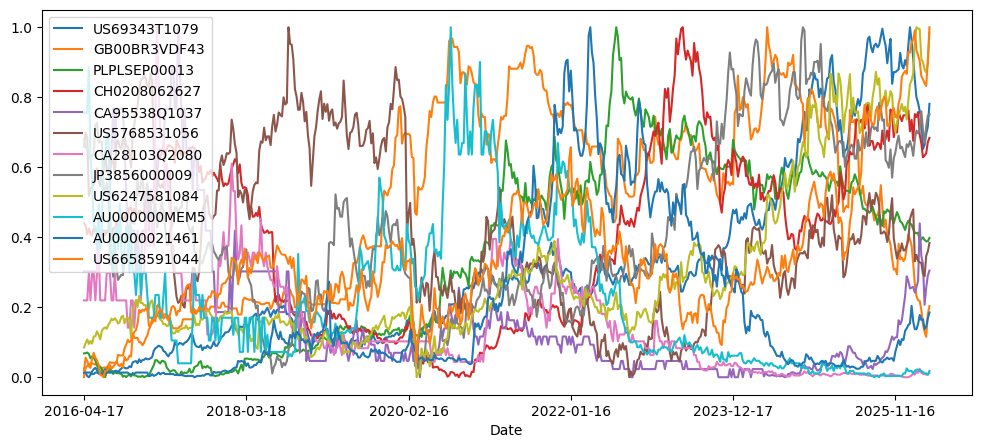

In [74]:
normalized_stocks = (stocks - stocks.min()) / (stocks.max() - stocks.min())
normalized_stocks[optimal_allocation.index].plot(figsize=(12, 5))

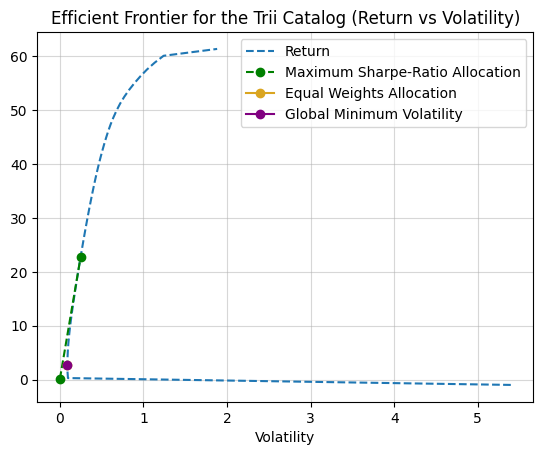

In [75]:
rk.plot_ef(50, style='--', show_cml=True, show_ew=True, show_gmv=True, riskfree_rate=rf_rate,
           returns=returns, covmat=covmat, periods_per_year=periods_per_year)
plt.title('Efficient Frontier for the Trii Catalog (Return vs Volatility)')
plt.grid(alpha=.5)

# **Create an index for the chosen allocation**

In [ ]:
# Generate a dataframe to represent the evolution of the allocation in each stock
weights = chosen_allocation['Weights']
allocated_index = (rets[weights.index] + 1).cumprod()*weights

# Add a column to represent the index
allocated_index['index'] = allocated_index.sum(axis='columns')
allocated_index.index = pd.to_datetime(allocated_index.index.str.split('/').str[0])

# Generate a row to represent an earlier period before returns are made,
# corresponding to the time when the index equal 1
first_period = allocated_index.index[0]
starting_period = first_period - pd.offsets.Week(weekday=6)   # Uncomment to generate a week starting period
#starting_period = first_period - pd.offsets.DateOffset(months=1)   # Uncomment to generate a month starting period
starting_period

allocation_start = pd.DataFrame(index=[starting_period], columns=allocated_index.columns)
allocation_start.iloc[:, :-1] = 1*weights
allocation_start['index'] = 1

# Append the row to the allocated_index dataframe
allocated_index = pd.concat([allocation_start, allocated_index], axis='rows')
allocated_index.head()

,BOGOTA.CL,ENELCHILE.SN,PFCIBEST.CL,NVDA,PBR,BVC.CL,COLBUN.SN,VOO,index
2016-04-10,0.077263,0.096995,0.111724,0.114334,0.149684,0.15,0.15,0.15,1.000000
2016-04-17,0.079838,0.096995,0.120478,0.119047,0.174935,0.155085,0.148562,0.152391,1.047331
2016-04-24,0.0811,0.096995,0.123511,0.11629,0.187431,0.158475,0.145086,0.153271,1.062159
2016-05-01,0.081126,0.088188,0.122125,0.113917,0.200707,0.155085,0.148029,0.15132,1.060497
2016-05-08,0.080519,0.089267,0.112764,0.113276,0.190815,0.151695,0.148445,0.150864,1.037644


In [ ]:
# Generate a dataframe with the returns of the index
allocated_index_returns = (allocated_index/allocated_index.shift(1) - 1).dropna()
allocated_index_returns.tail()

,BOGOTA.CL,ENELCHILE.SN,PFCIBEST.CL,NVDA,PBR,BVC.CL,COLBUN.SN,VOO,index
2026-03-08,-0.09807,-0.040383,-0.021063,0.003555,0.058328,-0.005882,-0.088407,-0.019983,0.004337
2026-03-15,0.018767,0.041369,-0.018304,0.013666,0.055114,-0.022485,-0.006491,-0.015103,0.014174
2026-03-22,-0.1,0.013699,0.05332,-0.041834,0.012386,0.0,-0.034488,-0.018306,-0.035461
2026-03-29,0.070175,-0.028514,-0.001553,-0.029994,0.104787,0.024213,-0.000787,-0.025053,-0.019286
2026-04-05,0.043049,0.042009,0.057437,0.058918,-0.010111,0.034279,0.055039,0.037624,0.052857


In [ ]:
summary_stats = rk.summary_stats(allocated_index_returns, periods_per_year=periods_per_year, riskfree_rate=0)
summary_stats

,Annualized Return,Annualized Volatility,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
BOGOTA.CL,0.019926,0.284626,-0.804036,12.131830,0.063816,0.100391,0.070006,-0.633000
ENELCHILE.SN,0.031145,0.321410,0.281154,6.002583,0.064212,0.096803,0.096900,-0.691931
PFCIBEST.CL,0.178720,0.310850,-0.175037,9.849369,0.061859,0.089149,0.574939,-0.536017
NVDA,0.734643,0.466096,0.359878,4.526729,0.083508,0.116430,1.576163,-0.659360
PBR,0.294703,0.486982,-0.173793,6.273022,0.100840,0.137473,0.605161,-0.710030
BVC.CL,0.144713,0.259348,0.736224,7.036828,0.044313,0.070308,0.557988,-0.356135
COLBUN.SN,-0.024561,0.344040,-1.024475,22.995388,0.070119,0.094113,-0.071389,-0.696125
VOO,0.148408,0.173690,-0.566171,9.114783,0.036775,0.054751,0.854440,-0.317619
index,0.407485,0.312908,0.119521,5.132193,0.059499,0.087667,1.302254,-0.468434


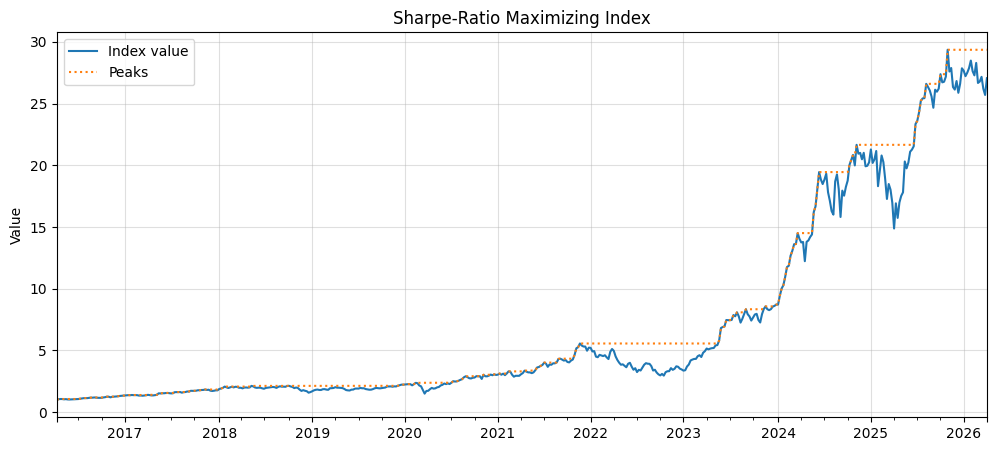

In [ ]:
# Visualize the evolution of the index
allocated_index['index'].plot(figsize=(12, 5), label='Index value')
allocated_index['index'].cummax().plot(linestyle=':', label='Peaks')
plt.legend()
plt.ylabel('Value')
plt.title('Sharpe-Ratio Maximizing Index')
plt.grid(alpha=0.4)

### **Export datasets and an index for the Sharpe-Ratio maximizing allocation**

In [ ]:
# Allocation index and returns
allocated_index.to_csv('../temp_references/allocated_index.csv')
allocated_index_returns.to_csv('../temp_references/allocated_index_returns.csv')